In [15]:
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    trasformation_X_to_E,
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    P_E_CMND
    )

In [16]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


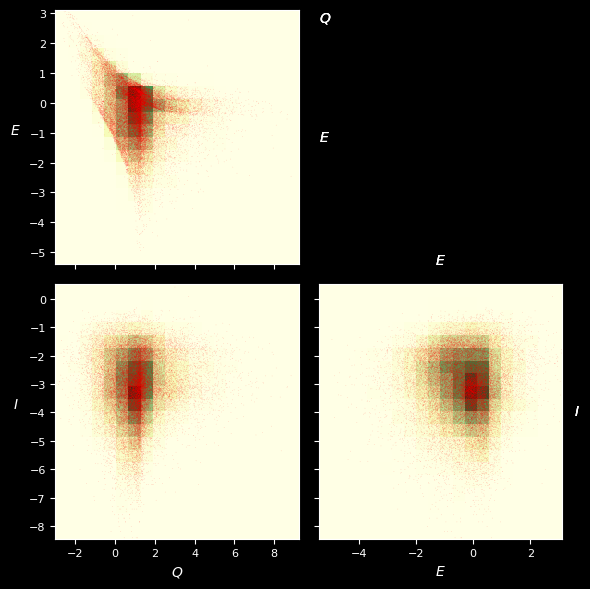

In [17]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [ ]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        #print("evaluating at: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        #print("orbital elements: ", q, e, i, Omega, w, M, a)
        if q > 1.35 or e >= 1:
            #print(" ----------------- Not sense orbit -----------------")
            P.flat[idx] = 0
        else:
            with np.errstate(divide='ignore', invalid='ignore'):
                J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
                J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
                det = np.linalg.det(J)
                det_QEI = np.linalg.det(J_qei_to_QEI)
                if det == 0 or not np.isfinite(det):
                    #print(" ----------------- Cero determinant -----------------")
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
                    #if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                    #    print("Nan value encounter: ", P_E_CMND(q, e, i, F), abs(inv_det), abs(det_QEI))
                    #print(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_AEI)) 
    
    return P.reshape(shape)

In [14]:
def box_surface_integral_P_X_CMND(center, widths, velocities, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the integral of P_X_CMND over a position box (x, y, z) with fixed velocities.
    Integrates only over positions in a box centered at (cx, cy, cz) with widths (dx, dy, dz),
    while keeping velocities constant (vx = cte, vy = cte, vz = cte).

    Parameters:
        center: tuple/list/array of (cx, cy, cz) position center
        widths: tuple/list/array of (dx, dy, dz) position side lengths
        velocities: tuple/list/array of (vx, vy, vz) constant velocities
        max_elements: tuple/list/array of (q_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension
        mu: gravitational parameter
        F: FitCMND object

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    cx, cy, cz = center
    dx, dy, dz = widths
    vx, vy, vz = velocities
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for position dimensions only
    x_pts = cx + 0.5*dx*pts
    y_pts = cy + 0.5*dy*pts
    z_pts = cz + 0.5*dz*pts

    # Create meshgrid only for position quadrature points
    X, Y, Z = np.meshgrid(x_pts, y_pts, z_pts, indexing='ij')
    WX, WY, WZ = np.meshgrid(wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    WF = (WX * WY * WZ).ravel()
    
    # Create constant velocity arrays (same size as position arrays)
    VXf = np.full_like(Xf, vx)
    VYf = np.full_like(Yf, vy)
    VZf = np.full_like(Zf, vz)
    
    # Evaluate P at all points with constant velocities
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor (only position dimensions)
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz)
    return integral

In [7]:
x_min, x_max = -2, 2
y_min, y_max = -2, 2

z_center = 0.0

dx_cell, dy_cell, dz_cell = 0.1, 0.1, 0.1
widths = np.array([dx_cell, dy_cell, dz_cell])

vx = 0.0
vy = (mu/1.0)**0.5
vz = 0.0
center_vel = np.array([vx, vy, vz])

max_elements = (1.35, 1.0, np.pi) 

x_vals = np.arange(x_min, x_max + dx_cell, dx_cell)
y_vals = np.arange(y_min, y_max + dy_cell, dy_cell)

degree = 6

dtype = [
    ("value", float),
    ("x", float),
    ("y", float)
]

probability_map = np.zeros((len(y_vals), len(x_vals)), dtype=dtype)

print("Starting probability mapping...")
for i, y_c in enumerate(tqdm(y_vals, desc="Y-axis progress")):
    for j, x_c in enumerate(x_vals):         

        center = np.array([x_c, y_c, z_center])

        try:
        # Calculate the integral for this hypervolume
            prob_value = box_surface_integral_P_X_CMND(
                center, widths, 
                center_vel, 
                max_elements, 
                degree, 
                mu=mu, 
                F=F
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = (prob_value, x_c, y_c)
        print(x_c, y_c, prob_value, i, j)
     
# Save to a .dat file
print("Mapping complete!")
np.save(f"data_results/method 6/PX_fixedv_xmin={x_min}_xmax={x_max}_ymin={y_min}_ymax={y_max}_vx={vx}_vy={np.round(vy, 2)}_vz={vz}_2.npy", probability_map)

Starting probability mapping...


Y-axis progress:   0%|          | 0/41 [00:00<?, ?it/s]

-2.0 -2.0 0.0 0 0
-1.9 -2.0 0.0 0 1
-1.7999999999999998 -2.0 0.0 0 2
-1.6999999999999997 -2.0 0.0 0 3
-1.5999999999999996 -2.0 0.0 0 4
-1.4999999999999996 -2.0 0.0 0 5
-1.3999999999999995 -2.0 0.0 0 6
-1.2999999999999994 -2.0 0.0 0 7
-1.1999999999999993 -2.0 0.0 0 8
-1.0999999999999992 -2.0 0.0 0 9
-0.9999999999999991 -2.0 0.0 0 10
-0.899999999999999 -2.0 0.0 0 11
-0.7999999999999989 -2.0 0.0 0 12
-0.6999999999999988 -2.0 0.0 0 13
-0.5999999999999988 -2.0 0.0 0 14
-0.49999999999999867 -2.0 0.0 0 15
-0.3999999999999986 -2.0 7.564061204767899e-41 0 16
Runtime error at center = [-0.3 -2.   0. ]
   → Setting integral to NaN.
-0.2999999999999985 -2.0 nan 0 17
Runtime error at center = [-0.2 -2.   0. ]
   → Setting integral to NaN.
-0.1999999999999984 -2.0 nan 0 18
Runtime error at center = [-0.1 -2.   0. ]
   → Setting integral to NaN.
-0.09999999999999831 -2.0 nan 0 19
Runtime error at center = [ 1.77635684e-15 -2.00000000e+00  0.00000000e+00]
   → Setting integral to NaN.
1.77635683940025

Y-axis progress:   2%|▏         | 1/41 [00:00<00:17,  2.34it/s]

0.8000000000000025 -2.0 0.0 0 28
0.9000000000000026 -2.0 0.0 0 29
1.0000000000000027 -2.0 0.0 0 30
1.1000000000000028 -2.0 0.0 0 31
1.2000000000000028 -2.0 0.0 0 32
1.300000000000003 -2.0 0.0 0 33
1.400000000000003 -2.0 0.0 0 34
1.500000000000003 -2.0 0.0 0 35
1.6000000000000032 -2.0 0.0 0 36
1.7000000000000033 -2.0 0.0 0 37
1.8000000000000034 -2.0 0.0 0 38
1.9000000000000035 -2.0 0.0 0 39
2.0000000000000036 -2.0 0.0 0 40
-2.0 -1.9 0.0 1 0
-1.9 -1.9 0.0 1 1
-1.7999999999999998 -1.9 0.0 1 2
-1.6999999999999997 -1.9 0.0 1 3
-1.5999999999999996 -1.9 0.0 1 4
-1.4999999999999996 -1.9 0.0 1 5
-1.3999999999999995 -1.9 0.0 1 6
-1.2999999999999994 -1.9 0.0 1 7
-1.1999999999999993 -1.9 0.0 1 8
-1.0999999999999992 -1.9 0.0 1 9
-0.9999999999999991 -1.9 0.0 1 10
-0.899999999999999 -1.9 0.0 1 11
-0.7999999999999989 -1.9 0.0 1 12
-0.6999999999999988 -1.9 5.595352271462659e-36 1 13
-0.5999999999999988 -1.9 1.682860479194385e-33 1 14
-0.49999999999999867 -1.9 1.4304382367551941e-32 1 15
-0.399999999999

...

0.8000000000000025 1.8000000000000034 5.562319406236349e-19 38 28
0.9000000000000026 1.8000000000000034 2.3309653022331366e-19 38 29
1.0000000000000027 1.8000000000000034 1.8825242064214551e-26 38 30
1.1000000000000028 1.8000000000000034 0.0 38 31
1.2000000000000028 1.8000000000000034 0.0 38 32
1.300000000000003 1.8000000000000034 0.0 38 33
1.400000000000003 1.8000000000000034 0.0 38 34
1.500000000000003 1.8000000000000034 0.0 38 35
1.6000000000000032 1.8000000000000034 0.0 38 36
1.7000000000000033 1.8000000000000034 0.0 38 37
1.8000000000000034 1.8000000000000034 0.0 38 38
1.9000000000000035 1.8000000000000034 0.0 38 39
2.0000000000000036 1.8000000000000034 0.0 38 40
-2.0 1.9000000000000035 0.0 39 0
-1.9 1.9000000000000035 0.0 39 1
-1.7999999999999998 1.9000000000000035 0.0 39 2
-1.6999999999999997 1.9000000000000035 0.0 39 3
-1.5999999999999996 1.9000000000000035 0.0 39 4
-1.4999999999999996 1.9000000000000035 0.0 39 5
-1.3999999999999995 1.9000000000000035 0.0 39 6
-1.29999999999999

Y-axis progress:  98%|█████████▊| 40/41 [06:52<00:08,  8.90s/it]

0.6000000000000023 1.9000000000000035 5.440752311602329e-25 39 26
0.7000000000000024 1.9000000000000035 1.204516817550125e-25 39 27
0.8000000000000025 1.9000000000000035 0.0 39 28
0.9000000000000026 1.9000000000000035 0.0 39 29
1.0000000000000027 1.9000000000000035 0.0 39 30
1.1000000000000028 1.9000000000000035 0.0 39 31
1.2000000000000028 1.9000000000000035 0.0 39 32
1.300000000000003 1.9000000000000035 0.0 39 33
1.400000000000003 1.9000000000000035 0.0 39 34
1.500000000000003 1.9000000000000035 0.0 39 35
1.6000000000000032 1.9000000000000035 0.0 39 36
1.7000000000000033 1.9000000000000035 0.0 39 37
1.8000000000000034 1.9000000000000035 0.0 39 38
1.9000000000000035 1.9000000000000035 0.0 39 39
2.0000000000000036 1.9000000000000035 0.0 39 40
-2.0 2.0000000000000036 0.0 40 0
-1.9 2.0000000000000036 0.0 40 1
-1.7999999999999998 2.0000000000000036 0.0 40 2
-1.6999999999999997 2.0000000000000036 0.0 40 3
-1.5999999999999996 2.0000000000000036 0.0 40 4
-1.4999999999999996 2.000000000000003

Y-axis progress: 100%|██████████| 41/41 [06:52<00:00, 10.06s/it]

Runtime error at center = [0.1 2.  0. ]
   → Setting integral to NaN.
0.10000000000000187 2.0000000000000036 nan 40 21
Runtime error at center = [0.2 2.  0. ]
   → Setting integral to NaN.
0.20000000000000195 2.0000000000000036 nan 40 22
Runtime error at center = [0.3 2.  0. ]
   → Setting integral to NaN.
0.30000000000000204 2.0000000000000036 nan 40 23
0.40000000000000213 2.0000000000000036 8.812947162705415e-36 40 24
0.5000000000000022 2.0000000000000036 0.0 40 25
0.6000000000000023 2.0000000000000036 0.0 40 26
0.7000000000000024 2.0000000000000036 0.0 40 27
0.8000000000000025 2.0000000000000036 0.0 40 28
0.9000000000000026 2.0000000000000036 0.0 40 29
1.0000000000000027 2.0000000000000036 0.0 40 30
1.1000000000000028 2.0000000000000036 0.0 40 31
1.2000000000000028 2.0000000000000036 0.0 40 32
1.300000000000003 2.0000000000000036 0.0 40 33
1.400000000000003 2.0000000000000036 0.0 40 34
1.500000000000003 2.0000000000000036 0.0 40 35
1.6000000000000032 2.0000000000000036 0.0 40 36
1.7

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_11480\3183872312.py:22: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


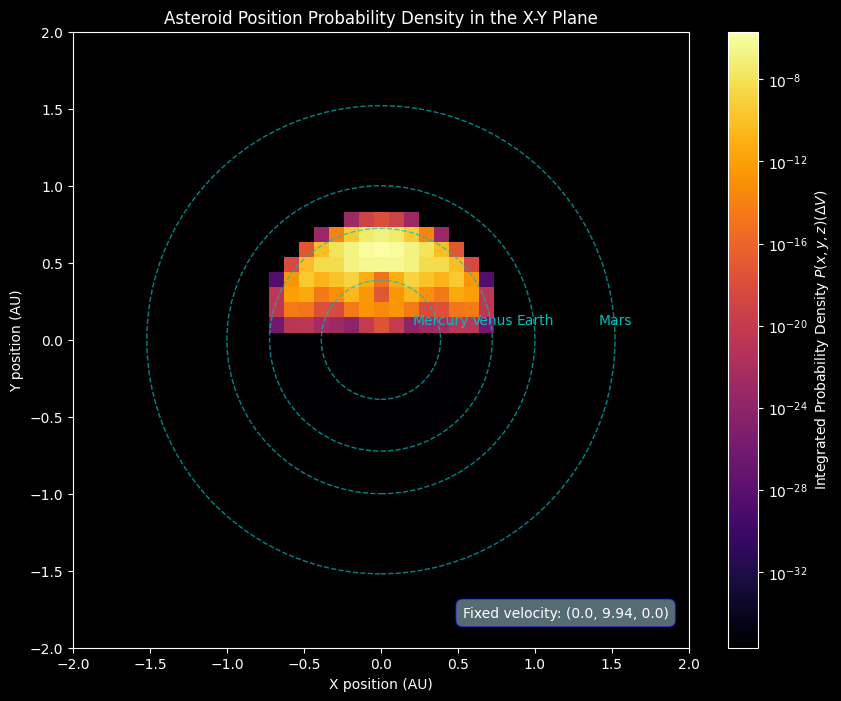

In [80]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=9.94_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = 9.94

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'].T, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest', 
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=9.94_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

In [91]:
integral_grid[15]

array([(0.00000000e+00, -2.00000000e+00, -0.5),
       (0.00000000e+00, -1.90000000e+00, -0.5),
       (0.00000000e+00, -1.80000000e+00, -0.5),
       (0.00000000e+00, -1.70000000e+00, -0.5),
       (0.00000000e+00, -1.60000000e+00, -0.5),
       (0.00000000e+00, -1.50000000e+00, -0.5),
       (0.00000000e+00, -1.40000000e+00, -0.5),
       (0.00000000e+00, -1.30000000e+00, -0.5),
       (0.00000000e+00, -1.20000000e+00, -0.5),
       (0.00000000e+00, -1.10000000e+00, -0.5),
       (0.00000000e+00, -1.00000000e+00, -0.5),
       (0.00000000e+00, -9.00000000e-01, -0.5),
       (0.00000000e+00, -8.00000000e-01, -0.5),
       (1.08189240e-34, -7.00000000e-01, -0.5),
       (1.16729022e-24, -6.00000000e-01, -0.5),
       (1.03480925e-22, -5.00000000e-01, -0.5),
       (1.56209280e-21, -4.00000000e-01, -0.5),
       (8.54159573e-21, -3.00000000e-01, -0.5),
       (1.03709425e-20, -2.00000000e-01, -0.5),
       (7.13735058e-22, -1.00000000e-01, -0.5),
       (1.42266355e-16,  1.77635684e-15,

In [92]:
integral_grid[25]

array([(0.00000000e+00, -2.00000000e+00, 0.5),
       (0.00000000e+00, -1.90000000e+00, 0.5),
       (0.00000000e+00, -1.80000000e+00, 0.5),
       (0.00000000e+00, -1.70000000e+00, 0.5),
       (0.00000000e+00, -1.60000000e+00, 0.5),
       (0.00000000e+00, -1.50000000e+00, 0.5),
       (0.00000000e+00, -1.40000000e+00, 0.5),
       (0.00000000e+00, -1.30000000e+00, 0.5),
       (0.00000000e+00, -1.20000000e+00, 0.5),
       (0.00000000e+00, -1.10000000e+00, 0.5),
       (0.00000000e+00, -1.00000000e+00, 0.5),
       (0.00000000e+00, -9.00000000e-01, 0.5),
       (0.00000000e+00, -8.00000000e-01, 0.5),
       (1.08189201e-34, -7.00000000e-01, 0.5),
       (1.16729022e-24, -6.00000000e-01, 0.5),
       (1.03480925e-22, -5.00000000e-01, 0.5),
       (1.56209280e-21, -4.00000000e-01, 0.5),
       (8.54159573e-21, -3.00000000e-01, 0.5),
       (1.03709425e-20, -2.00000000e-01, 0.5),
       (7.13735058e-22, -1.00000000e-01, 0.5),
       (1.42266355e-16,  1.77635684e-15, 0.5),
       (2.212

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_11480\1775542039.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


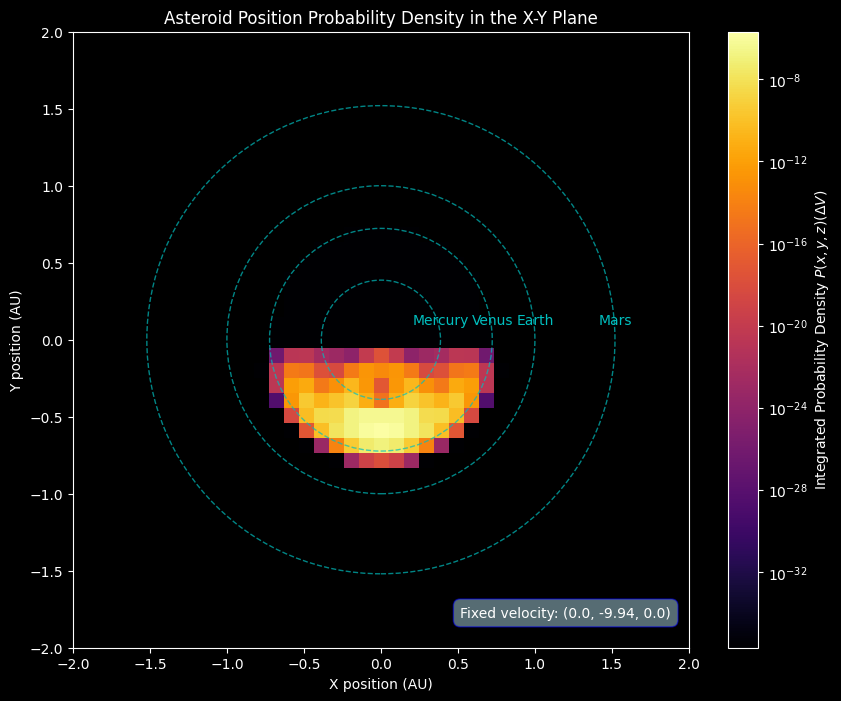

In [79]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-9.94_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = -9.94

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'].T,
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-9.94_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\2075011767.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


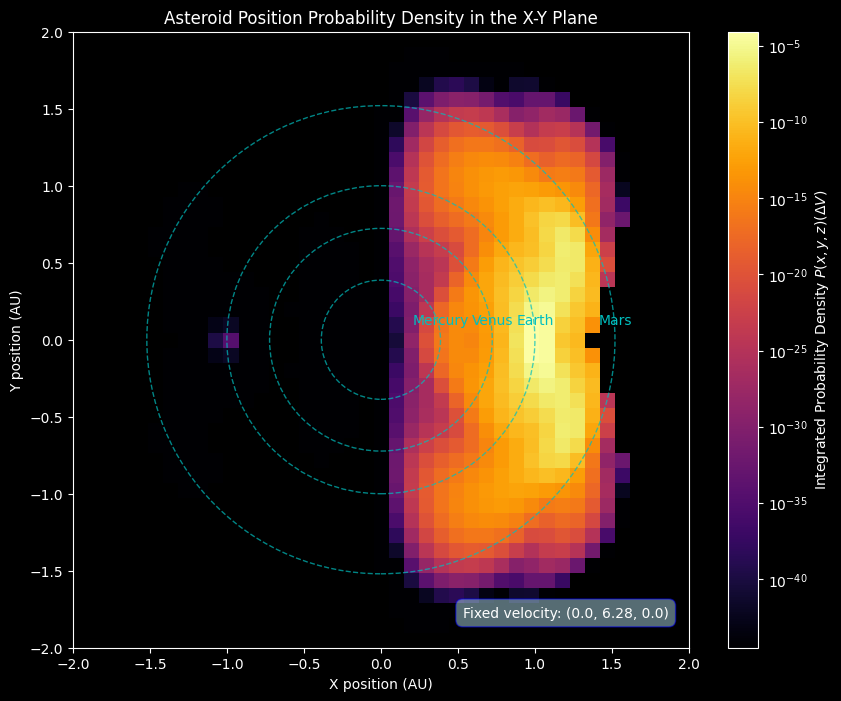

In [12]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = 6.28

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box')
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\3316823704.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


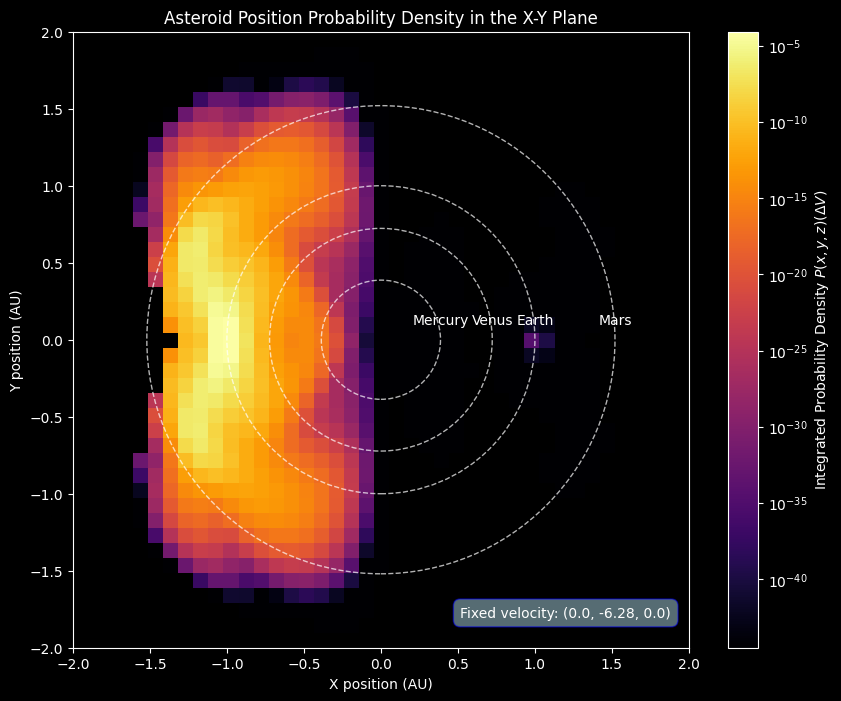

In [11]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-6.28_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = -6.28

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='white', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='white', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-6.28_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\3118552977.py:20: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


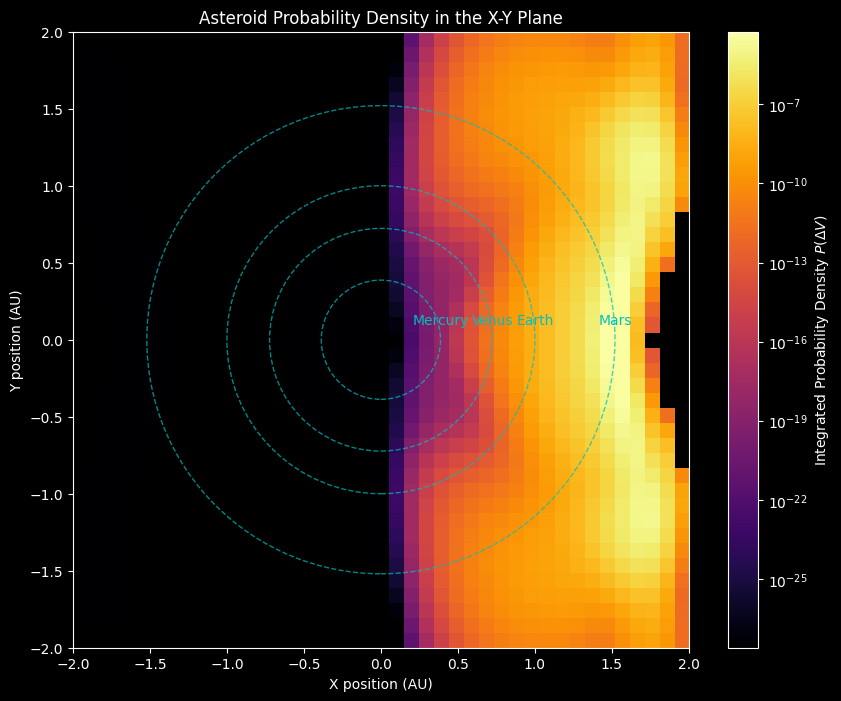

In [10]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=4.44_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\289382936.py:20: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


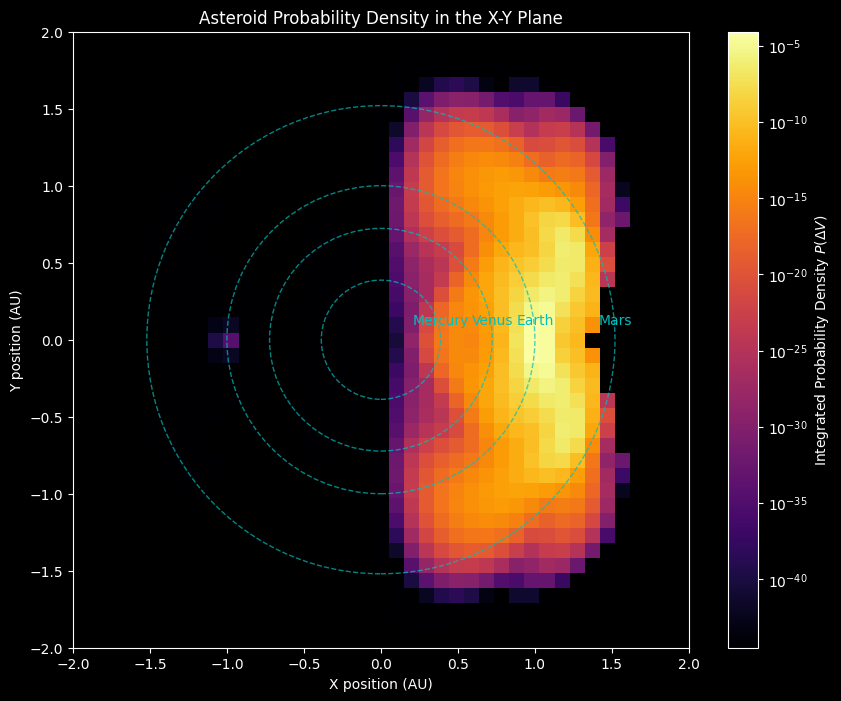

In [9]:

with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0_2.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()